In [ ]:
!/home/zyz/anaconda3/envs/py310/bin/python /home/zyz/workdir/Multi-View-ADD-main/train.py --loss_fn "all_loss"--gpu 1 --cfg MultiView/ASVSpoof5 -v 0 

In [ ]:
!/home/zyz/anaconda3/envs/py310/bin/python /home/zyz/workdir/branch1_dynamic_weight/train_controlled_MPE.py --gpu 0 --cfg MultiView/ASVSpoof5 -v 0 
!/home/zyz/anaconda3/envs/py310/bin/python /home/zyz/workdir/branch1_dynamic_weight/train_controlled_ABCNet.py --gpu 0 --cfg MultiView/ASVSpoof5 -v 0 

In [ ]:
!/home/zyz/anaconda3/envs/py310/bin/python /home/zyz/workdir/branch1_dynamic_weight/train_controlled_ABCNet.py --gpu 1 --cfg MultiView/ASVSpoof5 -v 0 

In [1]:
# Import necessary libraries
import matplotlib.pyplot as plt  # for plotting (optional)
import numpy as np  # for numerical computations
import torch
import torchvision
from torch.utils.data import DataLoader

In [ ]:
torch.manual_seed(42)
np.random.seed(42)

In [4]:
from data.tools.dataset import WaveDataset
from myutils.datasets.audio._ASV2021_LA import ASV2021LA_AudioDs


asv2021 = ASV2021LA_AudioDs(root_path="/home/zyz/data/LA_2021/ASVspoof2021_LA_eval")
ds = WaveDataset(data=asv2021.data.iloc[0:5])
ds[0]

{'sample_rate': 16000,
 'label': 0,
 'name': '/home/zyz/data/LA_2021/ASVspoof2021_LA_eval/wav/LA_E_1000048.wav',
 'vocoder_label': 2,
 'speed_label': 5,
 'compression_label': 0,
 'audio': tensor([[0.0000, 0.0000, 0.0000,  ..., 0.0003, 0.0003, 0.0002]])}

In [30]:
from controlled_ex.Aaasist.lit_aaasist import AASIST_lit


model = AASIST_lit(
    ckpt_path="/home/zyz/data/transfered_data/AASIST/ASV2021_LA/version_0/checkpoints/best-epoch=6-val-auc=0.9946.ckpt"
)
model = model.model

no. model params:297705


In [31]:
class tmpModel(torch.nn.Module):

    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x:torch.Tensor):
        

        n_fft = 512
        hop_length = 256
        
        # Compute STFT
        spec_f = torch.stft(
            x,
            n_fft=n_fft,
            hop_length=hop_length,
            return_complex=True,
            center=False
        )
        
        abs = spec_f.abs().pow(2)
        phase = spec_f.angle()
        
        # Combine magnitude and phase into a complex-valued tensor
        complex_spec_f = torch.polar(abs.sqrt(), phase)
        
        # Convert spectrogram back to audio (inverse STFT)
        reconstructed_audio = torch.istft(
            complex_spec_f,
            n_fft=n_fft,
            hop_length=hop_length,
            length=x.shape[-1]
        )
        # print(reconstructed_audio.shape, x.shape)
        feat, logits = self.model(reconstructed_audio)
        return feat, logits

In [32]:
model = tmpModel(model)
x = torch.randn(1, 48000)
model(x)

(tensor([[ 0.0000,  5.2673,  0.0000,  0.0000,  0.0000,  5.1557,  5.0470,  0.0000,
           8.1249,  4.1881,  4.5057,  3.5800,  2.8745,  0.0000,  0.0000,  0.0000,
           2.6351,  5.3067,  0.0000,  0.0000,  0.0000,  4.3423,  8.6550,  5.4506,
           7.1543,  4.9246,  0.0000,  0.0000,  0.0000,  5.1122,  8.7206,  5.1657,
           1.2451,  0.0000,  1.5528,  1.0819,  0.8515,  0.0000,  0.0000,  2.2988,
           4.1752,  0.7265,  0.0000,  0.0000,  1.0115,  0.0000,  0.0000,  0.6894,
           0.3173,  0.0000,  2.6873,  1.6818,  1.3615,  0.0000,  2.0921,  1.4993,
           0.0000,  0.6485,  0.0000,  0.6104,  0.0000,  1.7085,  0.0000,  2.0311,
           0.0000,  2.3011,  0.0000,  0.0000,  0.0000,  0.0000,  2.5741,  0.0000,
           0.0000,  0.0000,  0.0000,  6.0590,  2.6163,  0.0000,  0.0000,  3.9367,
           3.5096,  4.0444,  0.0000,  0.0000,  2.7406,  5.9255,  0.0000,  3.2684,
           0.0000,  3.1837,  6.8354,  4.5718,  0.0000,  2.2751,  4.3358,  2.7149,
           0.000

In [33]:

model

tmpModel(
  (model): Model(
    (conv_time): CONV()
    (first_bn): BatchNorm2d(1, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (drop): Dropout(p=0.5, inplace=True)
    (drop_way): Dropout(p=0.2, inplace=True)
    (selu): SELU(inplace=True)
    (encoder): Sequential(
      (0): Sequential(
        (0): Residual_block(
          (conv1): Conv2d(1, 32, kernel_size=(2, 3), stride=(1, 1), padding=(1, 1))
          (selu): SELU(inplace=True)
          (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(32, 32, kernel_size=(2, 3), stride=(1, 1), padding=(0, 1))
          (conv_downsample): Conv2d(1, 32, kernel_size=(1, 3), stride=(1, 1), padding=(0, 1))
          (mp): MaxPool2d(kernel_size=(1, 3), stride=(1, 3), padding=0, dilation=1, ceil_mode=False)
        )
      )
      (1): Sequential(
        (0): Residual_block(
          (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stat

In [34]:
x = torch.randn(2, 48000)
feat, logits = model(x)
print("Feature shape: ", feat.shape, "\nLogit shape:", logits.shape)

Feature shape:  torch.Size([2, 160]) 
Logit shape: torch.Size([2, 1])


## Apply Grad-CAM Technique to Generate Heatmap

In [35]:
import matplotlib as mpl
import matplotlib.collections as mcoll
import matplotlib.pyplot as plt
import numpy as np  # Make sure to import numpy as it's used in colorline


def multicolored_lines(x: np.ndarray, y: np.ndarray, heatmap: np.ndarray, title: str = None):
    """Plot a multicolored line chart based on x and y coordinates.

    This function takes in x and y coordinates and a heatmap to create a
    multicolored line plot. The colors of the line segments are determined
    by the values in the heatmap.

    Args:
        x (numpy.ndarray): A 1D array of x-coordinates.
        y (numpy.ndarray): A 1D array of y-coordinates.
        heatmap (numpy.ndarray): A 1D array of values used for coloring the line.
        title (str): The title of the plot.

    Returns:
        None: Displays the plot with a color bar indicating the heatmap values.

    Raises:
        ValueError: If the shapes of x, y, and heatmap are not compatible.
    """
    fig, ax = plt.subplots()
    lc = colorline(x, y, heatmap, cmap="rainbow")
    plt.colorbar(lc)
    lc.set_linewidth(2)
    lc.set_alpha(0.8)
    plt.xlim(x.min(), x.max())
    plt.ylim(y.min(), y.max())
    if title is not None:
        plt.title(title)
    plt.grid(False)
    plt.savefig("grad_cam.png")
    plt.show()


def colorline(x: np.ndarray, y: np.ndarray, heatmap: np.ndarray, cmap="rainbow"):
    """Create a LineCollection object for a multicolored line.

    This function generates a LineCollection from x and y coordinates, coloring
    the segments according to the heatmap values.

    Args:
        x (numpy.ndarray): A 1D array of x-coordinates.
        y (numpy.ndarray): A 1D array of y-coordinates.
        heatmap (numpy.ndarray): A 1D array of values used to color the line segments.
        cmap (str, optional): Colormap to use for coloring the segments (default is 'rainbow').

    Returns:
        matplotlib.collections.LineCollection: A LineCollection object representing the colored line.

    Raises:
        ValueError: If the lengths of x, y, and heatmap do not match.
    """
    z = np.array(heatmap)
    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    lc = mcoll.LineCollection(segments, array=z, cmap=cmap)
    ax = plt.gca()
    ax.add_collection(lc)
    return lc

In [36]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F


def target_category_loss(x, category_index, nb_classes):
    return torch.mul(x, F.one_hot(category_index, nb_classes))


def target_category_loss_output_shape(input_shape):
    return input_shape


def normalize(x):
    # utility function to normalize a tensor by its L2 norm
    return x / (torch.sqrt(torch.mean(torch.square(x))) + 1e-5)


class ActivationsAndGradients:
    """Class for extracting activations and
    registering gradients from targetted intermediate layers"""

    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = []
        self.activations = []

        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations.append(output)
        print("activations add: ", output.shape)
    
    def save_gradient(self, module, grad_input, grad_output):
        # Gradients are computed in reverse order
        self.gradients = [grad_output[0]] + self.gradients
        print("gradients add: ", grad_output[0].shape)

    def __call__(self, x):
        self.gradients = []
        self.activations = []
        return self.model(x)


class BaseCAM:
    def __init__(self, model, target_layer, use_cuda=False):
        self.model = model.eval()
        self.target_layer = target_layer
        self.cuda = use_cuda
        if self.cuda:
            self.model = model.cuda()

        self.activations_and_grads = ActivationsAndGradients(self.model, target_layer)

    def forward(self, input_img):
        return self.model(input_img)

    def get_cam_weights(self, input_tensor, target_category, activations, grads):
        raise Exception("Not Implemented")

    def get_loss(self, output, target_category):
        # print(output.size())
        # return output[target_category]
        return torch.sigmoid(output)

    def __call__(self, input_tensor, target_category=None):
        if self.cuda:
            input_tensor = input_tensor.cuda()

        feat, output = self.activations_and_grads(input_tensor)

        if target_category is None:
            output = output.squeeze()
            target_category = np.argmax(output.cpu().data.numpy())
            # print(output)
            # print(target_category)
        self.model.zero_grad()
        loss = self.get_loss(output, target_category)
        loss.backward(retain_graph=True)

        activations = self.activations_and_grads.activations[-1].cpu().data.numpy()[0, :]
        grads = self.activations_and_grads.gradients[-1].cpu().data.numpy()[0, :]
        # weights = np.mean(grads, axis=(0))
        weights = self.get_cam_weights(input_tensor, target_category, activations, grads)
        cam = np.zeros(activations.shape[1:], dtype=np.float32)
        for i, w in enumerate(weights):
            cam += w * activations[i, :]
        # cam = activations.T.dot(weights)
        # cam = activations.dot(weights)
        # cam = activations.dot(weights)
        # print(input_tensor.shape[1])
        # print(cam.shape)
        # x = np.arange(0, 247, 1)
        # plt.plot(x, cam.reshape(-1, 1))
        # sns.set()
        # ax = sns.heatmap(cam.reshape(-1, 1).T)
        # cam = cv2.resize(cam, input_tensor.shape[1:][::-1])
        # cam = resize_1d(cam, (input_tensor.shape[2]))

        print(input_tensor.shape)

        cam = np.interp(
            np.linspace(0, cam.shape[0], input_tensor.shape[1]), np.linspace(0, cam.shape[0], cam.shape[0]), cam
        )  # Change it to the interpolation algorithm that numpy comes with.
        # cam = np.maximum(cam, 0)
        # cam = np.expand_dims(cam, axis=1)
        # ax = sns.heatmap(cam)
        # plt.show()
        # cam = cam - np.min(cam)
        # cam = cam / np.max(cam)
        heatmap = (cam - np.min(cam)) / (np.max(cam) - np.min(cam) + 1e-10)  # 归一化处理
        # heatmap = (cam - np.mean(cam, axis=-1)) / (np.std(cam, axis=-1) + 1e-10)
        print(heatmap.shape)
        return heatmap, cam


class GradCAM(BaseCAM):
    def __init__(self, model, target_layer, use_cuda=False):
        super(GradCAM, self).__init__(model, target_layer, use_cuda)

    def get_cam_weights(self, input_tensor, target_category, activations, grads):
        grads_power_2 = grads**2
        grads_power_3 = grads_power_2 * grads
        sum_activations = np.sum(activations, axis=1)
        eps = 0.000001
        aij = grads_power_2 / (2 * grads_power_2 + sum_activations[:, None] * grads_power_3 + eps)
        aij = np.where(grads != 0, aij, 0)

        weights = np.maximum(grads, 0) * aij
        weights = np.sum(weights, axis=1)
        return weights

#### Select layers

In [37]:
# from pytorch_grad_cam.utils.image import preprocess_image
target_layer = model.model.pool_hT2
net = GradCAM(model, target_layer)

In [38]:
sample = ds[0]
input_tensor = sample["audio"][:, :48000]
output, unnormlized_cam = net(input_tensor, target_category=sample["label"])

activations add:  torch.Size([1, 6, 32])
gradients add:  torch.Size([1, 6, 32])
torch.Size([1, 40640])
(40640,)


In [39]:
output

array([0.56302909, 0.56319648, 0.56336387, ..., 0.51159084, 0.51137589,
       0.51116093])

In [40]:
input_tensor = input_tensor.numpy().squeeze()

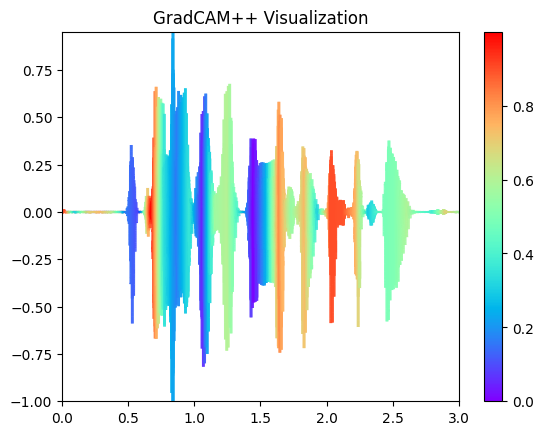

In [22]:
x = np.linspace(0, 3, input_tensor.shape[0])
multicolored_lines(x, input_tensor, output, f"GradCAM++ Visualization")

In [41]:
import librosa

In [42]:
from scipy.ndimage import gaussian_filter

smoothed_saliency = gaussian_filter(output, sigma=1)

In [43]:
def normalize(x):
    x_normalized = (x - x.min()) / (x.max() - x.min() + 1e-8)
    return x_normalized

In [44]:
import numpy as np
from scipy.signal import stft

# Compute spectrogram of the original waveform
f, t, original_spectrogram = stft(original_waveform, fs=sample_rate, nperseg=256)

# Weight the spectrogram by the saliency map
saliency_spectrogram = original_spectrogram * upsampled_saliency[: original_spectrogram.shape[1]]

# Normalize for visualization
saliency_spectrogram = np.abs(saliency_spectrogram)
saliency_spectrogram = (saliency_spectrogram - saliency_spectrogram.min()) / (
    saliency_spectrogram.max() - saliency_spectrogram.min() + 1e-8
)

NameError: name 'original_waveform' is not defined